

### 目標
本作業的核心是比較3種不同模型對預測效果的影響。
預測第 n+1 天的 close（收盤價）。

### 評估指標
- MSE


## Download Data and Import Libraries

In [ ]:
from pathlib import Path
from torchvision.datasets.utils import download_file_from_google_drive

csv_path_2308 = Path('./2308.csv')

if not csv_path_2308.exists():
    download_file_from_google_drive('1cRaFFJNaQYUewKHXoULhUTveuihOx6tU', '.', csv_path_2308)

Downloading...
From: https://drive.google.com/uc?id=1cRaFFJNaQYUewKHXoULhUTveuihOx6tU
To: /content/2308.csv
100%|██████████| 73.7k/73.7k [00:00<00:00, 29.3MB/s]


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader, Sampler

from sklearn.preprocessing import StandardScaler

In [ ]:
df_2308 = pd.read_csv(csv_path_2308)      # a DataFrame object
df_2308 = df_2308.sort_values(by='date')  # csv are not guarenteed to be ordered by date

df_2308.head(10)

,date,symbol,volume,open,high,low,close,transactions,daily_change_pct
6,2020/1/10,2308,6079101,152.5,154.5,149.5,151.0,2926,-0.0066
7,2020/1/13,2308,5115905,152.5,152.5,148.5,149.5,2963,-0.0099
8,2020/1/14,2308,4665147,150.5,151.5,149.5,151.0,2400,0.0100
9,2020/1/15,2308,9133097,151.0,151.0,147.5,148.5,3027,-0.0166
10,2020/1/16,2308,6949114,148.5,151.0,148.0,151.0,3646,0.0168
11,2020/1/17,2308,6215796,151.5,152.0,149.5,152.0,2833,0.0066
0,2020/1/2,2308,2721085,152.5,152.5,150.5,151.0,1764,0.0000
12,2020/1/20,2308,9947821,152.0,154.0,151.0,152.5,5624,0.0033
1,2020/1/3,2308,6932546,152.0,152.5,149.0,151.5,3386,0.0033
13,2020/1/30,2308,14343231,151.0,151.0,142.0,143.0,6747,-0.0623


### Train/Valid Split and Feature Normalization

We split first 85% of the entries to be training data, and last 15% to be validation data.
The pivot date is 2015-12-15, i.e., entries after 2015-12-15 (included) is valid data.


Note that scale of the features (`open`, `close`, `low`, `high`, `volume`) are different to each other. In practice, we normalize each features to better train our model. If we do so, the model will suffer gradient vanishment/exploding.

To normalize data, common techniques are:

1. Standard Scaler: $x_{new} = (x - mean) / std$
2. Minmax Scaler: $x_{new} = (x - x_{min}) / (x_{max} - x_{min})$

Both are implemented in `sklearn`. In this code, we use the first one.

**Be careful that when normalizing data, we can use only training data to compute the statistics. Using validation/testing data is not allowed.**


In some cases, we need to obtain original values from normalized features, we can do it using the standard scaler `std` used for normalization.

```python
raw_open = normalize_open* std.scale_[0] + std.mean_[0]
raw_close = normalized_close * std.scale_[1] + std.mean_[1]
raw_low = normalized_low * std.scale_[2] + std.mean_[2]
raw_high = normalized_low * std.scale_[3] + std.mean_[3]
raw_volume = normalized_low * std.scale_[4] + std.mean_[4]
```

In [ ]:
pivot = round(0.85 * len(df_2308))
print('pivot:', df_2308.loc[pivot, 'date'])

df_train = df_2308[:pivot].copy()    # DataFrame
df_valid = df_2308[pivot:].copy()    # DataFrame

FEATURES_STD = ['open', 'close', 'low', 'high', 'volume']
std = StandardScaler().fit(df_train[FEATURES_STD])
df_train[FEATURES_STD] = std.transform(df_train[FEATURES_STD])
df_valid[FEATURES_STD] = std.transform(df_valid[FEATURES_STD])

df_train.head(10)

pivot: 2024/4/9


,date,symbol,volume,open,high,low,close,transactions,daily_change_pct
6,2020/1/10,2308,-0.327612,-1.756288,-1.753827,-1.768659,-1.777471,2926,-0.0066
7,2020/1/13,2308,-0.552411,-1.756288,-1.785213,-1.784659,-1.801259,2963,-0.0099
8,2020/1/14,2308,-0.657612,-1.788023,-1.800906,-1.768659,-1.777471,2400,0.0100
9,2020/1/15,2308,0.385155,-1.780090,-1.808753,-1.800659,-1.817119,3027,-0.0166
10,2020/1/16,2308,-0.124561,-1.819758,-1.808753,-1.792659,-1.777471,3646,0.0168
11,2020/1/17,2308,-0.295709,-1.772156,-1.793060,-1.768659,-1.761611,2833,0.0066
0,2020/1/2,2308,-1.111334,-1.756288,-1.785213,-1.752659,-1.777471,1764,0.0000
12,2020/1/20,2308,0.575302,-1.764222,-1.761674,-1.744659,-1.753682,5624,0.0033
1,2020/1/3,2308,-0.128428,-1.764222,-1.785213,-1.776659,-1.769541,3386,0.0033
13,2020/1/30,2308,1.601139,-1.780090,-1.808753,-1.888659,-1.904345,6747,-0.0623


# Dataset

To predict the stock close on day 16 based on day 1 ~ day 15 features, we expect each sample contains:

1. feature: the features of day 1 ~ 15. Each day has 5 features (open, close, low, high, volume), thus the shape is [15, 5].
2. target: the target we are predicting. In this case, it is the close of day 16, thus target is shaped [1].

Therefore we are performing a sliding window-like operation on the given dataframe.

In [ ]:
class CompanyStockData(Dataset):
    def __init__(self, dataframe, window=10):
        super().__init__()
        self.df = dataframe
        self.window = window

    def __len__(self):
        return len(self.df) - self.window

    def __getitem__(self, idx):
        window_s = idx
        window_t = idx + self.window
        feature = self.df.iloc[window_s:window_t - 1]
        feature = feature[['open', 'close', 'low', 'high', 'volume']].values
        feature = torch.from_numpy(feature).float()

        target = self.df.iloc[window_t - 1]
        target = target['close'].item()
        target = torch.tensor([target]).float()
        return feature, target

WINDOW = 20
train_set = CompanyStockData(df_train, window=WINDOW)
valid_set = CompanyStockData(df_valid, window=WINDOW)

train_loader = DataLoader(train_set, shuffle=True, batch_size=8, num_workers=0)
valid_loader = DataLoader(valid_set, shuffle=False, batch_size=8, num_workers=0)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"使用裝置: {device}")

使用裝置: cpu


# Model

We implements following model:



In [ ]:
import math
import torch
import torch.nn as nn

class TransformerModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim=1, nhead=4, dropout=0.1):
        super(TransformerModel, self).__init__()

        # 為了保持與您原本初始化宣告 (input_dim, hidden_dim, layer_dim) 的參數相容：
        # 我們將 hidden_dim 作為 Transformer 的 d_model 維度
        # 將 layer_dim 作為 Transformer Encoder 的層數 (num_layers)
        self.hidden_dim = hidden_dim

        # 1. 線性投射層：將輸入特徵維度 (input_dim) 對應到 Transformer 的 hidden_dim 維度
        self.input_linear = nn.Linear(input_dim, hidden_dim)

        # 2. 位置編碼 (Positional Encoding)，隨機初始化一個可訓練的 Parameter
        # 預設最大時間步長度設為 100 (對應您的 time step / window size)
        self.pos_encoder = nn.Parameter(torch.zeros(1, 100, hidden_dim))

        # 3. Transformer 編碼器層
        # 注意：nhead (多頭注意力) 必須要能被 hidden_dim 整除。
        # 如果您的 hidden_dim 是 32, nhead=4 可以整除 (32/4=8)。
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=nhead,
            dim_feedforward=hidden_dim * 2,
            dropout=dropout,
            batch_first=True  # 確保接受 [batch_size, seq_len, features] 的輸入格式
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=layer_dim)

        # 4. 輸出層：將 Transformer 的輸出映射到預測目標 (維度為 output_dim，預設為 1)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x 的維度為: [batch_size, seq_len, input_dim]
        seq_len = x.size(1)

        # 投射到 hidden_dim 維度並縮放
        out = self.input_linear(x) * math.sqrt(self.hidden_dim)

        # 加上位置編碼 (利用 broadcasting 自動對齊 batch 軸)
        out = out + self.pos_encoder[:, :seq_len, :]

        # 通過 Transformer Encoder -> 輸出形狀仍為 [batch_size, seq_len, hidden_dim]
        out = self.transformer_encoder(out)

        # 依據時間序列預測習慣，取最後一個時間步 (Sequence 的最後一天) 的輸出進行預測
        out = out[:, -1, :]

        # 透過全連接層得到最終預測股價 [batch_size, output_dim]
        out = self.fc(out)
        return out

Some other RNN model you can try:

# Training

Train the model in standard way and record losses every epoch.

In [ ]:
@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()

    preds, trues = [], []

    # 自動偵測裝置
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 直接從指定的 DataLoader 中迭代提取特徵與解答
    for feature_b, target_b in loader:
        # 將輸入資料送至 GPU/CPU 運算，並轉回 CPU
        predict_b = model(feature_b.to(device)).to('cpu')

        preds.extend(predict_b)
        trues.extend(target_b)

    # 將結果堆疊並壓平成一維 numpy 陣列，避免維度錯位
    preds = torch.stack(preds).numpy().flatten()
    trues = torch.stack(trues).numpy().flatten()

    # 💡 由於您在 CompanyStockData 中設定的 target 是 target['close'].item() (第三張圖)
    # 這代表您正在預測的是「收盤價 close」，所以我們這裡必須為您保留「反標準化還原」的機制！
    CLOSE_IDX = FEATURES_STD.index('close')
    preds = preds * std.scale_[CLOSE_IDX] + std.mean_[CLOSE_IDX]
    trues = trues * std.scale_[CLOSE_IDX] + std.mean_[CLOSE_IDX]

    # 計算評估指標 (MSE 與 MAE)
    mse = ((preds - trues) ** 2).mean()
    mae = np.abs(preds - trues).mean()

    return preds, trues, mse, mae

In [ ]:
import torch
from tqdm.notebook import tqdm

# =====================================================================
# 核心設定：宣告與實例化專屬的 Transformer 模型
# =====================================================================
models_to_test = {
    'Transformer': TransformerModel(input_dim=5, hidden_dim=32, layer_dim=3, output_dim=1)
}

# 用於儲存所有模型的歷史數據與預測結果
all_histories = {}
results = {}

# 調整訓練輪數為 30
EPOCHS = 30

# 自動偵測 GPU / CPU 裝置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# =====================================================================
# 開始 Transformer 模型訓練
# =====================================================================
for name, model in models_to_test.items():
    print(f"\n-------- 🚀 開始訓練模型：{name} --------")

    # 確保模型權重搬移到指定裝置
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {'train_loss': [], 'valid_loss': []}

    for epoch in tqdm(range(EPOCHS), desc=f"{name} 訓練進度"):
        # --- Train 模式 ---
        model.train()
        train_losses = []
        for feature_b, target_b in train_loader:
            feature_b, target_b = feature_b.to(device), target_b.to(device)

            optimizer.zero_grad()
            predict_b = model(feature_b)
            loss = criterion(predict_b, target_b)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        # --- Valid 模式 ---
        model.eval()
        valid_losses = []
        with torch.no_grad():
            for feature_b, target_b in valid_loader:
                feature_b, target_b = feature_b.to(device), target_b.to(device)

                predict_b = model(feature_b)
                loss = criterion(predict_b, target_b)
                valid_losses.append(loss.item())

        # 計算當前 Epoch 平均 Loss
        current_train_loss = sum(train_losses) / len(train_losses)
        current_valid_loss = sum(valid_losses) / len(valid_losses)

        history['train_loss'].append(current_train_loss)
        history['valid_loss'].append(current_valid_loss)

        # 每 5 次（或是最後一次）列出一次訓練結果
        if (epoch + 1) % 5 == 0 or epoch == EPOCHS - 1:
            print(f"Epoch [{epoch+1:02d}/{EPOCHS}]: Train Loss = {current_train_loss:.6f} | Valid Loss = {current_valid_loss:.6f}")

    # --- 將模型的歷史紀錄存入字典 ---
    all_histories[name] = history

    # =====================================================================
    # 🛠️ 終極對齊修正：直接將現有的 train_loader 與 valid_loader 傳入評估
    # =====================================================================
    train_preds, train_trues, train_mse, train_mae = evaluate_model(model, train_loader)
    valid_preds, valid_trues, valid_mse, valid_mae = evaluate_model(model, valid_loader)

    # 將結果存入字典，後續畫圖與文字報告就能完美讀取
    results[name] = {
        'train_preds': train_preds, 'train_trues': train_trues, 'train_mse': train_mse, 'train_mae': train_mae,
        'valid_preds': valid_preds, 'valid_trues': valid_trues, 'valid_mse': valid_mse, 'valid_mae': valid_mae
    }
    print(f"✨ {name} 訓練與評估完成！ 最終 Valid MSE: {valid_mse:.6f} | 最終 Valid MAE: {valid_mae:.6f}")


-------- 🚀 開始訓練模型：Transformer --------


Transformer 訓練進度:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch [05/30]: Train Loss = 0.048992 | Valid Loss = 0.172046
Epoch [10/30]: Train Loss = 0.045000 | Valid Loss = 0.093360
Epoch [15/30]: Train Loss = 0.041850 | Valid Loss = 0.104786
Epoch [20/30]: Train Loss = 0.038256 | Valid Loss = 0.132798
Epoch [25/30]: Train Loss = 0.038113 | Valid Loss = 0.103265
Epoch [30/30]: Train Loss = 0.037828 | Valid Loss = 0.110771
✨ Transformer 訓練與評估完成！ 最終 Valid MSE: 444.611312 | 最終 Valid MAE: 15.434780



-------- 📊 正在繪製綜合對比圖表... --------


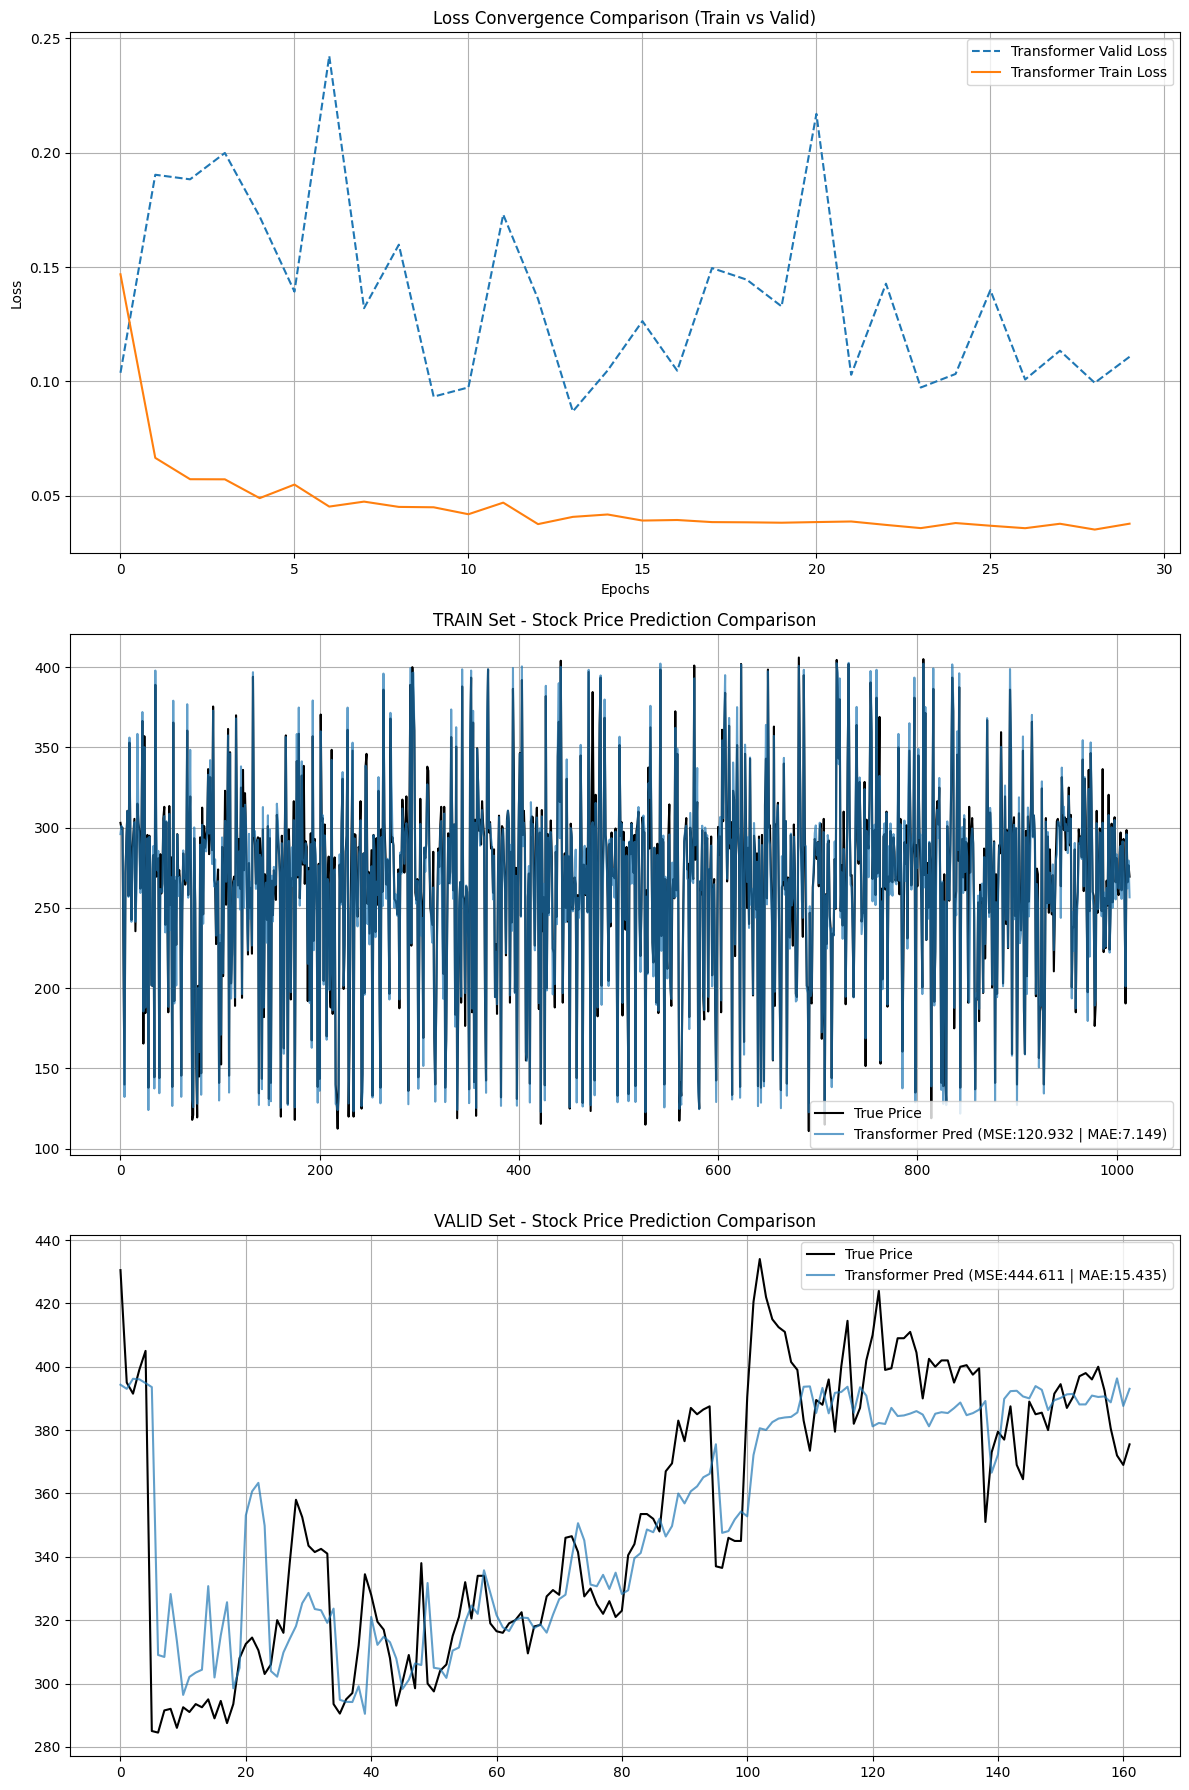


----------------------------------------
🔥  最終效能總結報告  🔥
----------------------------------------
[Transformer]
    - 訓練集 (Train) -> 最終 MSE: 120.932 | 最終 MAE: 7.149
    - 驗證集 (Valid) -> 最終 MSE: 444.611 | 最終 MAE: 15.435


In [ ]:
import matplotlib.pyplot as plt

print("\n-------- 📊 正在繪製綜合對比圖表... --------")

# 建立 3 個子圖
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# =====================================================================
# 📊 圖(一)：Loss 曲線對比
# =====================================================================
for name in models_to_test.keys():
    if name in all_histories:
        axes[0].plot(all_histories[name]['valid_loss'], label=f'{name} Valid Loss', linestyle='--')
        axes[0].plot(all_histories[name]['train_loss'], label=f'{name} Train Loss')

axes[0].set_title('Loss Convergence Comparison (Train vs Valid)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# 找出目前 results 字典裡第一個有資料的模型名稱，用來畫黑色基準線 (True Price)
available_names = [name for name in models_to_test.keys() if name in results]

if available_names:
    any_name = available_names[0]

    # =====================================================================
    # 📊 圖(二)：訓練集預測結果 (只畫真實值一次，疊加各模型預測)
    # =====================================================================
    axes[1].plot(results[any_name]['train_trues'], label='True Price', color='black', linewidth=1.5)

    for name in models_to_test.keys():
        if name in results:
            mse = results[name]['train_mse']
            mae = results[name]['train_mae']  # 💡 撈出訓練集 MAE
            # 💡 修改處：將 Train MAE 也顯示在圖例上
            axes[1].plot(results[name]['train_preds'], label=f'{name} Pred (MSE:{mse:.3f} | MAE:{mae:.3f})', alpha=0.7)

    axes[1].set_title('TRAIN Set - Stock Price Prediction Comparison')
    axes[1].legend()
    axes[1].grid(True)

    # =====================================================================
    # 📊 圖(三)：驗證集預測結果 (加上最終 Valid MSE 與 Valid MAE)
    # =====================================================================
    axes[2].plot(results[any_name]['valid_trues'], label='True Price', color='black', linewidth=1.5)

    for name in models_to_test.keys():
        if name in results:
            mse = results[name]['valid_mse']  # 最終 Valid MSE
            mae = results[name]['valid_mae']  # 最終 Valid MAE
            # 💡 核心修改處：直接把最終的 Valid MSE 和 Valid MAE 一併塞進圖例標籤裡！
            axes[2].plot(results[name]['valid_preds'], label=f'{name} Pred (MSE:{mse:.3f} | MAE:{mae:.3f})', alpha=0.7)

    axes[2].set_title('VALID Set - Stock Price Prediction Comparison')
    axes[2].legend()
    axes[2].grid(True)

plt.tight_layout()
plt.show()

# =====================================================================
# 📝 列印最後的文字版效能總結
# =====================================================================
print("\n" + "-"*40 + "\n🔥  最終效能總結報告  🔥\n" + "-"*40)

for name in models_to_test.keys():
    if name in results:
        print(f"[{name}]")
        # 💡 同時清晰列印出訓練集與驗證集的最終 MSE 與 MAE
        print(f"    - 訓練集 (Train) -> 最終 MSE: {results[name]['train_mse']:.3f} | 最終 MAE: {results[name]['train_mae']:.3f}")
        print(f"    - 驗證集 (Valid) -> 最終 MSE: {results[name]['valid_mse']:.3f} | 最終 MAE: {results[name]['valid_mae']:.3f}")

In [ ]:
!pip install onnxscript onnx
import torch
import os
from google.colab import files

print("\n-------- 📦 開始將模型轉換為 ONNX 格式 --------")

# =====================================================================
# 1. 定義虛擬輸入 (Dummy Input)
# 根據您的 CompanyStockData 切片：window_s:window_t - 1，實際時間步長度為 WINDOW - 1 (20 - 1 = 19)
# =====================================================================
WINDOW = 20
current_window_size = WINDOW - 1  # 19 步
dummy_input = torch.randn(1, current_window_size, 5).to('cpu')

# =====================================================================
# 2. 依序轉換每個模型
# =====================================================================
for name, model in models_to_test.items():
    # 將模型移回 CPU 並設定為評估模式（這對 Transformer/LSTM 的 Dropout 非常重要）
    model_cpu = model.to('cpu')
    model_cpu.eval()

    onnx_filename = f"{name}_stock_model.onnx"

    # 使用 try-except 保護，避免多模型切換時因為單一模型出錯而中斷
    try:
        torch.onnx.export(
            model_cpu,
            dummy_input,
            onnx_filename,
            export_params=True,        # 包含訓練好的權重參數
            opset_version=18,          # 💡 核心修正：升級到 opset 18，Transformer 導出才不會報錯
            do_constant_folding=True,  # 執行常數折疊優化
            input_names=['input_features'],   # 自訂輸入節點名稱
            output_names=['predict_price'],   # 自訂輸出節點名稱
            # 允許隨後的部署環境動態調整 Batch Size (例如一次預測 1 筆或 32 筆)
            dynamic_axes={
                'input_features': {0: 'batch_size'},
                'predict_price': {0: 'batch_size'}
            }
        )
        print(f"✅ 成功轉換: {onnx_filename}")
    except Exception as e:
        print(f"❌ 模型 {name} 轉換 ONNX 失敗！錯誤訊息: {e}")

print("\n-------- 📥 正在為您下載 ONNX 檔案至本地... --------")

# =====================================================================
# 3. 自動觸發瀏覽器下載所有成功轉換的 ONNX 檔案
# =====================================================================
for name in models_to_test.keys():
    onnx_filename = f"{name}_stock_model.onnx"
    if os.path.exists(onnx_filename):
        files.download(onnx_filename)
    else:
        print(f"⚠️ 找不到檔案 {onnx_filename}，跳過下載。")


-------- 📦 開始將模型轉換為 ONNX 格式 --------


/tmp/ipykernel_2511/1207302712.py:28: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `TransformerModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `TransformerModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
✅ 成功轉換: Transformer_stock_model.onnx

-------- 📥 正在為您下載 ONNX 檔案至本地... --------


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Reading package lists...
Building dependency tree...
Reading state information...
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
=== 📊 Transformer 股票預測模型結構圖 ===


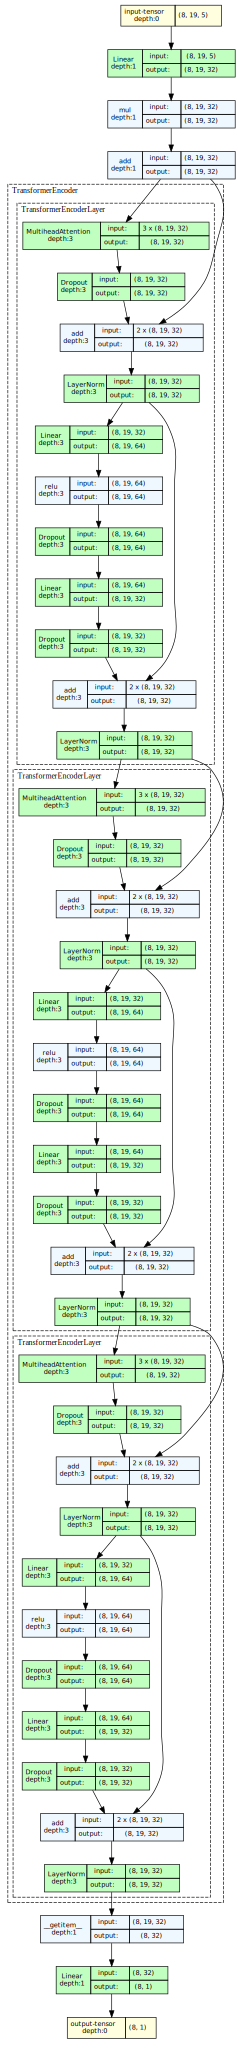


系統提示：Transformer 模型的 PNG 圖片已成功儲存至 Colab 左側的檔案資料夾中，可直接下載用於期末專題報告！


In [ ]:
# =====================================================================
# 1. 安裝與匯入繪圖所需套件
# =====================================================================
!pip install torchview graphviz -q

import math
import torch
import torch.nn as nn
from torchview import draw_graph
import matplotlib.pyplot as plt

# 確保 Graphviz 命令列工具正常運作
!apt-get install graphviz -y -q

# =====================================================================
# 2. 定義您的 Transformer 模型架構 (與您的 ipynb 專案完全一致)
# =====================================================================
class TransformerModel(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=32, layer_dim=3, output_dim=1, nhead=4, dropout=0.1):
        super(TransformerModel, self).__init__()
        self.hidden_dim = hidden_dim

        # 1. 線性投射層
        self.input_linear = nn.Linear(input_dim, hidden_dim)

        # 2. 位置編碼 (隨機初始化一個可訓練的 Parameter)
        self.pos_encoder = nn.Parameter(torch.zeros(1, 100, hidden_dim))

        # 3. Transformer 編碼器層
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=nhead,
            dim_feedforward=hidden_dim * 2,
            dropout=dropout,
            batch_first=True  # 確保接受 [batch_size, seq_len, features] 的輸入格式
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=layer_dim)

        # 4. 輸出層
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        seq_len = x.size(1)

        # 投射至 hidden_dim 並縮放
        out = self.input_linear(x) * math.sqrt(self.hidden_dim)

        # 加上位置編碼 (利用 broadcasting 自動對齊 batch 軸)
        out = out + self.pos_encoder[:, :seq_len, :]

        # 通過 Transformer Encoder
        out = self.transformer_encoder(out)

        # 取最後一個時間步
        out = out[:, -1, :]

        # 全連接層輸出
        out = self.fc(out)
        return out

# =====================================================================
# 3. 實例化模型並繪製圖表
# =====================================================================
# 設定與專案對齊的資料形狀：Batch=8, Sequence_Length=19, Features=5
input_data_shape = (8, 19, 5)

# 實例化專案參數 (input_dim=5, hidden_dim=32, layer_dim=3, output_dim=1)
model_transformer = TransformerModel(input_dim=5, hidden_dim=32, layer_dim=3, output_dim=1)

# 使用 torchview 繪製計算圖
graph_transformer = draw_graph(
    model_transformer,
    input_size=input_data_shape,
    graph_name="Transformer_Stock_Architecture",
    expand_nested=True,  # 展開內部的多頭自注意力與 FeedForward 子層
    depth=3              # 控制展示的深度
)

print("=== 📊 Transformer 股票預測模型結構圖 ===")
display(graph_transformer.visual_graph)

# =====================================================================
# 4. 將結構圖儲存為報告用圖片 (PNG 格式)
# =====================================================================
graph_transformer.visual_graph.render("Transformer_stock_model", format="png")
print("\n系統提示：Transformer 模型的 PNG 圖片已成功儲存至 Colab 左側的檔案資料夾中，可直接下載用於期末專題報告！")